# NB04 — Integrated Gradients Map Generation
**Project:** CNN vs ViT Localization Faithfulness in Chest X-Ray  
**Plan version:** v7.1  
**Stage 4a:** Run after NB03 is complete and all 3 checkpoints exist.

---

### What this notebook does
1. Mounts Drive and loads config + thresholds  
2. Loads `test_patho.csv` and `test_healthy.csv`  
3. Loads all 3 model checkpoints (DenseNet121, ConvNeXtV2-Tiny, Swin-B+LoRA)  
4. Generates Integrated Gradients maps via Captum — zero baseline, n_steps=300  
5. Convergence gate: if `|delta| > 0.01` → re-runs at `n_steps=500`  
6. Saves per-image normalised IG map + top-30/50/70% binarised masks as `.npy`  
7. Saves `results/convergence_errors.csv`  
8. Runs Monotonicity metric on saved maps → `results/monotonicity_results.csv`  
9. Runs Deletion/Insertion AUC (tertiary) → `results/deletion_insertion.csv`  
10. Saves `results/ig_manifest.csv` consumed by NB05 and NB06

### Outputs
```text
ig_maps/
  {image_id}_{model}_ig.npy
  {image_id}_{model}_ig_top30.npy
  {image_id}_{model}_ig_top50.npy
  {image_id}_{model}_ig_top70.npy

results/
  ig_manifest.csv
  convergence_errors.csv
  monotonicity_results.csv
  deletion_insertion.csv
```

### Notes
- IG is the primary XAI method for all three models.
- Zero baseline is used for all models.
- If `abs(delta) > 0.01`, the sample is rerun with `n_steps=500`.
- Swin-B LoRA must use `target_modules=['qkv', 'proj']`.
- This notebook does **not** overwrite NB03 outputs such as `classification_baseline.csv`.

### Pre-flight checklist
- [ ] Runtime → Change runtime type → **T4 GPU**
- [ ] NB01 complete: `test_patho.csv`, `test_healthy.csv`, PNGs exist
- [ ] NB02 complete: all 3 `.pt` checkpoints, `thresholds.json`, `lora_sweep.csv`
- [ ] NB03 complete


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

GDRIVE_ROOT = '/content/drive/MyDrive/cxr_faithfulness'
exec(open(f'{GDRIVE_ROOT}/config/startup.py').read())


Mounted at /content/drive
⏳ Installing strictly pinned architecture packages onto Colab's native stack (~30s)...
✅ Packages ready! Using native modern PyTorch and NumPy.


## Cell 2 — Pinned installs


In [ ]:
# !pip install -q   torch==2.2.1   torchvision==0.17.1   timm==0.9.12   captum==0.7.0   peft==0.6.2   opencv-python-headless   statsmodels==0.14.0 || exit 1
import torch
assert torch.cuda.is_available(), "GPU not available. Runtime → Change runtime type → GPU"
print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   torch: {torch.__version__}")

✅ GPU: Tesla T4
   VRAM: 15.6 GB
   torch: 2.11.0+cu128


## Cell 3 — Imports, paths, constants


In [ ]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import gc
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path

import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as tvmodels
import timm
from torch.amp import autocast
from captum.attr import IntegratedGradients
from peft import LoraConfig, TaskType, get_peft_model

ROOT = Path(GDRIVE_ROOT)
IMAGES_PATH = ROOT / 'data' / 'processed' / 'images'
SPLITS_PATH = ROOT / 'data' / 'processed' / 'splits'
MODELS_PATH = ROOT / 'models'
RESULTS_PATH = ROOT / 'results'
IG_PATH = ROOT / 'ig_maps'
IG_TOP30_PATH = IG_PATH / 'top30'
IG_TOP50_PATH = IG_PATH / 'top50'
IG_TOP70_PATH = IG_PATH / 'top70'

RESULTS_PATH.mkdir(parents=True, exist_ok=True)
IG_PATH.mkdir(parents=True, exist_ok=True)
IG_TOP30_PATH.mkdir(parents=True, exist_ok=True)
IG_TOP50_PATH.mkdir(parents=True, exist_ok=True)
IG_TOP70_PATH.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
NUM_CLASSES = 14
RANDOM_SEED = 42
IG_STEPS = 300
DELTA_THRESH = 0.01
MONO_STEPS = 100
DELIN_STEPS = 100
SAVE_EVERY = 100

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

MODEL_NAMES = ['densenet121', 'convnextv2_tiny', 'swinb_lora']

print("✅ Imports and paths ready.")

✅ Imports and paths ready.


## Cell 4 — Reproducibility seed


In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_SEED)
print(f"✅ Seed set: {RANDOM_SEED}")


✅ Seed set: 42


## Cell 5 — Load LoRA rank and thresholds


In [ ]:
sweep_path = MODELS_PATH / 'lora_sweep.csv'
assert sweep_path.exists(), f"❌ lora_sweep.csv not found at {sweep_path}. Run NB02 first."
sweep_df = pd.read_csv(str(sweep_path))
assert 'rank' in sweep_df.columns, f"'rank' column missing. Found: {sweep_df.columns.tolist()}"
assert 'val_auc' in sweep_df.columns, f"'val_auc' column missing. Found: {sweep_df.columns.tolist()}"
selected_rank = int(sweep_df.loc[sweep_df['val_auc'].idxmax(), 'rank'])
print(f"✅ LoRA rank: r{selected_rank}")

thresh_path = MODELS_PATH / 'thresholds.json'
assert thresh_path.exists(), f"❌ thresholds.json not found at {thresh_path}. Run NB02 first."
with open(str(thresh_path)) as f:
    all_thresholds = json.load(f)

for mn in MODEL_NAMES:
    assert mn in all_thresholds, f"❌ Model key '{mn}' not found in thresholds.json. Keys: {list(all_thresholds.keys())}"

print("✅ thresholds.json loaded and all model keys verified.")


✅ LoRA rank: r32
✅ thresholds.json loaded and all model keys verified.


## Cell 6 — Dataset and DataLoaders


In [ ]:
test_patho_csv = SPLITS_PATH / 'test_patho.csv'
test_healthy_csv = SPLITS_PATH / 'test_healthy.csv'

assert test_patho_csv.exists(), f"❌ test_patho.csv not found at {test_patho_csv}. Run NB01 Step 1.4 first."
assert test_healthy_csv.exists(), f"❌ test_healthy.csv not found at {test_healthy_csv}. Run NB01 Step 1.4 first."

test_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CXRDataset(Dataset):
    def __init__(self, csv_path: Path, images_path: Path, transform=None):
        self.df = pd.read_csv(str(csv_path))
        self.images_path = Path(images_path)
        self.transform = transform
        self.label_cols = [c for c in self.df.columns if c != 'image_id']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_path = self.images_path / f"{row['image_id']}.png"
        img = cv2.imread(str(img_path))
        if img is None:
            raise FileNotFoundError(f"Image not found: {img_path}. Run NB01 first.")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        labels = torch.tensor(row[self.label_cols].values.astype(float), dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, labels, str(row['image_id'])

patho_ds = CXRDataset(test_patho_csv, IMAGES_PATH, test_transforms)
healthy_ds = CXRDataset(test_healthy_csv, IMAGES_PATH, test_transforms)
assert patho_ds.label_cols == healthy_ds.label_cols, 'Label columns mismatch between subsets'

patho_loader = DataLoader(patho_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
healthy_loader = DataLoader(healthy_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

LABEL_COLS = patho_ds.label_cols

assert len(LABEL_COLS) == NUM_CLASSES, (
    f"❌ CSV has {len(LABEL_COLS)} label columns but NUM_CLASSES={NUM_CLASSES}. "
    f"Re-run NB01 with corrected class list."
)
print(f"✅ LABEL_COLS count matches NUM_CLASSES: {NUM_CLASSES}")

print(f"✅ Patho images   : {len(patho_ds)}")
print(f"✅ Healthy images : {len(healthy_ds)}")
print(f"✅ Classes        : {len(LABEL_COLS)}")
print(f"✅ Labels         : {LABEL_COLS}")


✅ LABEL_COLS count matches NUM_CLASSES: 14
✅ Patho images   : 461
✅ Healthy images : 1039
✅ Classes        : 14
✅ Labels         : ['Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass', 'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']


## Cell 7 — Model loader


In [ ]:
def load_model(model_name: str, models_path: Path, selected_rank: int, num_classes: int) -> nn.Module:
    if model_name == 'densenet121':
        m = tvmodels.densenet121(weights=None)
        m.classifier = nn.Linear(1024, num_classes)

    elif model_name == 'convnextv2_tiny':
        m = timm.create_model(
            'convnextv2_tiny.fcmae_ft_in22k_in1k',
            pretrained=False,
            num_classes=0,
        )
        m.head.fc = nn.Linear(768, num_classes)

    elif model_name == 'swinb_lora':
        base = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False,
            num_classes=num_classes,
        )
        lora_cfg = LoraConfig(
            r=selected_rank,
            lora_alpha=selected_rank * 2,
            target_modules=['qkv', 'proj'],
            lora_dropout=0.1,
            bias='none',
            task_type=TaskType.FEATURE_EXTRACTION,
        )
        m = get_peft_model(base, lora_cfg)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    ckpt_path = models_path / f'{model_name}_finetuned.pt'
    assert ckpt_path.exists(), f"❌ Checkpoint not found: {ckpt_path}. Run NB02 first."
    state = torch.load(str(ckpt_path), map_location='cpu')

    state_keys = set(state.keys())
    lora_query_keys = {k for k in state_keys if 'query.lora' in k or 'value.lora' in k}
    if model_name == 'swinb_lora' and lora_query_keys:
        raise RuntimeError(
            f"❌ Checkpoint was trained with target_modules=['query','value'] (plan v7.0). "
            f"NB02 must be rerun with target_modules=['qkv','proj']. "
            f"Conflicting keys: {list(lora_query_keys)[:4]}"
        )

    m.load_state_dict(state)
    m = m.cuda().eval()
    if model_name == 'swinb_lora':
        m.forward = base.forward
    print(f"✅ {model_name} loaded from {ckpt_path.name}")
    return m

print("Model loader defined.")


Model loader defined.


## Cell 8 — IG helper functions


In [ ]:
def normalize_ig_map(attr: np.ndarray) -> np.ndarray:
    attr = np.abs(attr)
    if attr.ndim == 3:
        attr = attr.sum(axis=0)
    mn, mx = attr.min(), attr.max()
    if (mx - mn) < 1e-8:
        return np.zeros_like(attr, dtype=np.float32)
    return ((attr - mn) / (mx - mn)).astype(np.float32)


def top_mass_mask(attr_map: np.ndarray, mass: float = 0.5) -> np.ndarray:
    flat = attr_map.flatten().astype(np.float32)
    order = np.argsort(flat)[::-1]
    vals = flat[order]
    csum = np.cumsum(vals)
    total = csum[-1]

    if total <= 0:
        return np.zeros_like(attr_map, dtype=np.uint8)

    cutoff = int(np.searchsorted(csum, mass * total, side='left')) + 1
    keep_idx = order[:cutoff]

    mask = np.zeros_like(flat, dtype=np.uint8)
    mask[keep_idx] = 1
    return mask.reshape(attr_map.shape)


def get_target_class(model: nn.Module, img_tensor: torch.Tensor, label_cols: list, thresholds_dict: dict):
    with torch.inference_mode():
        with autocast('cuda'):
            logits = model(img_tensor)
            probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()

    above = [i for i, cls in enumerate(label_cols) if probs[i] >= thresholds_dict.get(cls, 0.5)]
    if above:
        target_idx = int(max(above, key=lambda i: probs[i]))
    else:
        target_idx = int(np.argmax(probs))
    return target_idx, probs


def run_ig(model: nn.Module, img_tensor: torch.Tensor, target_idx: int, n_steps: int):
    ig = IntegratedGradients(model)
    baseline = torch.zeros_like(img_tensor)
    attr, delta = ig.attribute(
            img_tensor,
            baselines=baseline,
            target=target_idx,
            n_steps=n_steps,
            internal_batch_size=50,
            return_convergence_delta=True,
        )
    return attr.detach().cpu().numpy()[0], float(delta.detach().cpu().item())


def compute_ig_with_convergence_check(model: nn.Module, img_tensor: torch.Tensor, target_idx: int):
    attr_raw, initial_delta = run_ig(model, img_tensor, target_idx, IG_STEPS)
    rerun = abs(initial_delta) > DELTA_THRESH
    steps_used = IG_STEPS
    final_delta = initial_delta

    if rerun:
        attr_raw, final_delta = run_ig(model, img_tensor, target_idx, 500)
        steps_used = 500

    attr_norm = normalize_ig_map(attr_raw)
    return attr_norm, initial_delta, final_delta, steps_used, rerun


print("✅ IG helper functions defined.")


✅ IG helper functions defined.


## Cell 9 — Monotonicity helper


In [ ]:
def compute_monotonicity(
    model: nn.Module,
    img_tensor: torch.Tensor,
    attr_map: np.ndarray,
    target_idx: int,
    steps: int = MONO_STEPS,
):
    n = attr_map.size
    flat_rank = np.argsort(attr_map.flatten())[::-1]
    baseline = torch.zeros_like(img_tensor)

    masks = np.zeros((steps, n), dtype=np.float32)
    for k in range(1, steps + 1):
        keep_n = max(1, int(n * k / steps))
        masks[k-1, flat_rank[:keep_n]] = 1.0

    mask_tensor = (
        torch.from_numpy(masks)
        .reshape(steps, 1, IMG_SIZE, IMG_SIZE)
        .to(img_tensor.device)
    )

    x_batch = img_tensor * mask_tensor + baseline * (1.0 - mask_tensor)

    curve = []
    model.eval()
    with torch.inference_mode():
        with autocast('cuda'):
            for i in range(0, steps, 50):
                logits = model(x_batch[i:i+50])
                confs = torch.sigmoid(logits)[:, target_idx].cpu().numpy()
                curve.extend(confs.tolist())

    mono_auc = float(np.trapz(curve) / (steps - 1))
    is_mono = all(curve[i] <= curve[i + 1] + 1e-6 for i in range(len(curve) - 1))
    return curve, mono_auc, is_mono


print("✅ Monotonicity helper defined (Optimized Batched).")


✅ Monotonicity helper defined (Optimized Batched).


## Cell 10 — Deletion / Insertion AUC helper


In [ ]:
def compute_deletion_insertion(
    model: nn.Module,
    img_tensor: torch.Tensor,
    attr_map: np.ndarray,
    target_idx: int,
    steps: int = DELIN_STEPS,
):
    n = attr_map.size
    flat_rank = np.argsort(attr_map.flatten())[::-1]
    img_np = img_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)
    blurred_np = cv2.GaussianBlur(img_np, (0, 0), sigmaX=10)
    baseline = torch.from_numpy(np.ascontiguousarray(blurred_np.transpose(2, 0, 1))).unsqueeze(0).to(img_tensor.device)

    masks = np.zeros((steps, n), dtype=np.float32)
    for k in range(1, steps + 1):
        keep_n = max(1, int(n * k / steps))
        masks[k-1, flat_rank[:keep_n]] = 1.0

    mask_tensor = (
        torch.from_numpy(masks)
        .reshape(steps, 1, IMG_SIZE, IMG_SIZE)
        .to(img_tensor.device)
    )

    x_del = img_tensor * (1.0 - mask_tensor) + baseline * mask_tensor
    x_ins = baseline * (1.0 - mask_tensor) + img_tensor * mask_tensor

    del_curve = []
    ins_curve = []

    model.eval()
    with torch.inference_mode():
        with autocast('cuda'):
            for i in range(0, steps, 50):
                del_logits = model(x_del[i:i+50])
                del_confs = torch.sigmoid(del_logits)[:, target_idx].cpu().numpy()
                del_curve.extend(del_confs.tolist())

            for i in range(0, steps, 50):
                ins_logits = model(x_ins[i:i+50])
                ins_confs = torch.sigmoid(ins_logits)[:, target_idx].cpu().numpy()
                ins_curve.extend(ins_confs.tolist())

    del_auc = float(np.trapz(del_curve) / (steps - 1))
    ins_auc = float(np.trapz(ins_curve) / (steps - 1))
    return del_auc, ins_auc


print("✅ Deletion/Insertion helper defined (Optimized Batched).")


✅ Deletion/Insertion helper defined (Optimized Batched).


## Cell 11 — Save manifest and convergence CSV


In [11]:
set_seed(RANDOM_SEED)

manifest_csv   = RESULTS_PATH / 'ig_manifest.csv'
conv_csv       = RESULTS_PATH / 'convergence_errors.csv'
manifest_partial = RESULTS_PATH / 'ig_manifest_partial.csv'

if manifest_csv.exists() and not manifest_partial.exists():
    raise RuntimeError("❌ ig_manifest.csv exists. Delete it first if you want to rerun from scratch.")
if manifest_partial.exists():
    _existing = pd.read_csv(str(manifest_partial))
    manifest_rows = _existing.to_dict('records')
    _done_manifest = set(zip(_existing['image_id'], _existing['model']))
    print(f"Resuming manifest — {len(manifest_rows)} rows already done.")
else:
    manifest_rows = []
    _done_manifest = set()

conv_partial = RESULTS_PATH / 'convergence_partial.csv'
if conv_partial.exists():
    try:
        _existing_conv = pd.read_csv(str(conv_partial))
    except pd.errors.EmptyDataError:
        _existing_conv = pd.DataFrame(columns=['image_id', 'model', 'predicted_class', 'delta', 'ig_steps'])
    convergence_rows = _existing_conv.to_dict('records')
    print(f"Resuming convergence — {len(convergence_rows)} rows already done.")
else:
    convergence_rows = []

for model_name in MODEL_NAMES:
    print(f"{'='*60}")
    print(f"Generating IG maps — {model_name}")
    print(f"{'='*60}")

    model = load_model(model_name, MODELS_PATH, selected_rank, NUM_CLASSES)
    model_thresholds = all_thresholds[model_name]

    missing_keys = set(LABEL_COLS) - set(model_thresholds.keys())
    assert not missing_keys, (
        f"❌ Threshold keys missing for {model_name}: {missing_keys}\n"
        f"   CSV cols : {LABEL_COLS}\n"
        f"   JSON keys: {list(model_thresholds.keys())}"
    )

    for subset_name, loader in [('patho', patho_loader), ('healthy', healthy_loader)]:
        print(f"Subset: {subset_name} ({len(loader.dataset)} images)")
        n_processed = 0
        n_skipped = 0

        for imgs, labels, image_ids in loader:
            image_id = image_ids[0]

            if (image_id, model_name) in _done_manifest:
                n_processed += 1
                continue

            img_tensor = imgs.cuda()
            labels_np = labels.numpy()[0]

            target_idx, probs = get_target_class(model, img_tensor, LABEL_COLS, model_thresholds)

            if subset_name == 'healthy':
                if probs[target_idx] < model_thresholds.get(LABEL_COLS[target_idx], 0.5):
                    n_skipped += 1
                    continue

            if subset_name == 'patho':
                if labels_np.sum() < 0.5:
                    n_skipped += 1
                    continue

            base = f'{image_id}_{model_name}'
            npy_path = IG_PATH / f'{base}_ig.npy'
            top30_path = IG_TOP30_PATH / f'{base}_ig_top30.npy'
            top50_path = IG_TOP50_PATH / f'{base}_ig_top50.npy'
            top70_path = IG_TOP70_PATH / f'{base}_ig_top70.npy'

            files_exist = (
                npy_path.exists()
                and top30_path.exists()
                and top50_path.exists()
                and top70_path.exists()
            )

            if files_exist:
                manifest_rows.append({
                    'image_id': image_id,
                    'model': model_name,
                    'subset': subset_name,
                    'target_class': LABEL_COLS[target_idx],
                    'target_idx': target_idx,
                    'ig_path': str(npy_path),
                    'top30_path': str(top30_path),
                    'top50_path': str(top50_path),
                    'top70_path': str(top70_path),
                    'final_delta': np.nan,
                    'steps_used': np.nan,
                    'recovered_from_disk': True,
                })
                n_processed += 1
                if n_processed % SAVE_EVERY == 0:
                    print(f' [{n_processed}] processed, [{n_skipped}] skipped...')
                    pd.DataFrame(manifest_rows).to_csv(str(manifest_partial), index=False)
                    pd.DataFrame(convergence_rows).to_csv(str(conv_partial), index=False)
                continue

            attr_norm, init_delta, final_delta, steps_used, rerun = compute_ig_with_convergence_check(
                model, img_tensor, target_idx
            )
            torch.cuda.empty_cache()

            top30 = top_mass_mask(attr_norm, 0.30)
            top50 = top_mass_mask(attr_norm, 0.50)
            top70 = top_mass_mask(attr_norm, 0.70)

            np.save(str(npy_path), attr_norm)
            np.save(str(top30_path), top30)
            np.save(str(top50_path), top50)
            np.save(str(top70_path), top70)

            manifest_rows.append({
                'image_id': image_id,
                'model': model_name,
                'subset': subset_name,
                'target_class': LABEL_COLS[target_idx],
                'target_idx': target_idx,
                'ig_path': str(npy_path),
                'top30_path': str(top30_path),
                'top50_path': str(top50_path),
                'top70_path': str(top70_path),
                'final_delta': round(final_delta, 6),
                'steps_used': steps_used,
                'recovered_from_disk': False,
            })

            convergence_rows.append({
                'image_id': image_id,
                'model': model_name,
                'subset': subset_name,
                'initial_delta': round(init_delta, 6),
                'final_delta': round(final_delta, 6),
                'steps_used': steps_used,
                'recovered_from_disk': False,
                'rerun_flag': rerun,
            })

            n_processed += 1
            if n_processed % SAVE_EVERY == 0:
                print(f' [{n_processed}] processed, [{n_skipped}] skipped...')
                pd.DataFrame(manifest_rows).to_csv(str(manifest_partial), index=False)
                pd.DataFrame(convergence_rows).to_csv(str(conv_partial), index=False)

        print(f"✅ {model_name}/{subset_name}: {n_processed} new, {n_skipped} skipped.")

    del model
    gc.collect()
    torch.cuda.empty_cache()

print("✅ IG generation complete.")
print(f"Manifest rows : {len(manifest_rows)}")
print(f"Convergence rows : {len(convergence_rows)}")
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(RESULTS_PATH / 'ig_manifest.csv', index=False)

convergence_df = pd.DataFrame(convergence_rows)
convergence_df.to_csv(RESULTS_PATH / 'convergence_errors.csv', index=False)

for p in [manifest_partial, conv_partial]:
    if p.exists(): p.unlink()

print(f"✅ ig_manifest.csv saved with {len(manifest_df)} rows")
print(f"✅ convergence_errors.csv saved with {len(convergence_df)} rows")

Resuming manifest — 400 rows already done.
Generating IG maps — densenet121
✅ densenet121 loaded from densenet121_finetuned.pt
Subset: patho (461 images)
✅ densenet121/patho: 461 new, 0 skipped.
Subset: healthy (1039 images)
✅ densenet121/healthy: 53 new, 986 skipped.
Generating IG maps — convnextv2_tiny
✅ convnextv2_tiny loaded from convnextv2_tiny_finetuned.pt
Subset: patho (461 images)
 [100] processed, [0] skipped...
 [200] processed, [0] skipped...
 [300] processed, [0] skipped...
 [400] processed, [0] skipped...
✅ convnextv2_tiny/patho: 461 new, 0 skipped.
Subset: healthy (1039 images)
✅ convnextv2_tiny/healthy: 51 new, 988 skipped.
Generating IG maps — swinb_lora


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


✅ swinb_lora loaded from swinb_lora_finetuned.pt
Subset: patho (461 images)
 [100] processed, [0] skipped...
 [200] processed, [0] skipped...
 [300] processed, [0] skipped...
 [400] processed, [0] skipped...
✅ swinb_lora/patho: 461 new, 0 skipped.
Subset: healthy (1039 images)
✅ swinb_lora/healthy: 41 new, 998 skipped.
✅ IG generation complete.
Manifest rows : 1528
Convergence rows : 435
✅ ig_manifest.csv saved with 1528 rows
✅ convergence_errors.csv saved with 435 rows


## Cell 13 — Phase B: Monotonicity metric


In [12]:
if 'test_transforms' not in globals():
    raise RuntimeError("❌ transform undefined. Run the top cells first.")

set_seed(RANDOM_SEED)

mono_out_path = RESULTS_PATH / 'monotonicity_results.csv'
mono_partial_path = RESULTS_PATH / 'monotonicity_partial.csv'

if mono_partial_path.exists():
    done_df = pd.read_csv(str(mono_partial_path))
    done_keys = set(zip(done_df['image_id'], done_df['model']))
    mono_rows = done_df.to_dict('records')
    print(f"Resuming monotonicity — {len(mono_rows)} rows already done.")
else:
    done_keys = set()
    mono_rows = []

manifest_df = pd.read_csv(RESULTS_PATH / 'ig_manifest.csv')

for model_name in MODEL_NAMES:
    print(f"{'='*60}")
    print(f"Monotonicity — {model_name}")
    print(f"{'='*60}")

    model = load_model(model_name, MODELS_PATH, selected_rank, NUM_CLASSES)

    model_rows = manifest_df[manifest_df['model'] == model_name].to_dict('records')

    for row in model_rows:
        key = (row['image_id'], row['model'])
        if key in done_keys:
            continue

        ig_path = Path(row['ig_path'])
        assert ig_path.exists(), f"❌ Missing IG map: {ig_path}"
        ig_map = np.load(str(ig_path))

        img_p = IMAGES_PATH / f"{row['image_id']}.png"
        img = cv2.imread(str(img_p))
        assert img is not None, f"❌ Could not read image: {img_p}"
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_t = test_transforms(img).unsqueeze(0).cuda()

        target_idx = int(row['target_idx'])

        curve, mono_auc, is_mono = compute_monotonicity(model, img_t, ig_map, target_idx)
        torch.cuda.empty_cache()

        mono_rows.append({
            'image_id': row['image_id'],
            'model': model_name,
            'subset': row['subset'],
            'target_class': row['target_class'],
            'monotonicity_auc': round(mono_auc, 6),
            'is_monotone': is_mono,
        })
        done_keys.add(key)

        if len(mono_rows) % SAVE_EVERY == 0:
            pd.DataFrame(mono_rows).to_csv(str(mono_partial_path), index=False)
            print(f" [{len(mono_rows)}] monotonicity rows saved (checkpoint)...")

    del model
    gc.collect()
    torch.cuda.empty_cache()

mono_df = pd.DataFrame(mono_rows)
mono_df.to_csv(str(mono_out_path), index=False)

if mono_partial_path.exists():
    mono_partial_path.unlink()

print(f"✅ monotonicity_results.csv saved: {len(mono_df)} rows")
print("Mean Mono AUC per model:")
print(mono_df.groupby('model')['monotonicity_auc'].mean().round(4).to_string())


Monotonicity — densenet121
✅ densenet121 loaded from densenet121_finetuned.pt


/tmp/ipykernel_3820/1720013038.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mono_auc = float(np.trapz(curve) / (steps - 1))


 [100] monotonicity rows saved (checkpoint)...
 [200] monotonicity rows saved (checkpoint)...
 [300] monotonicity rows saved (checkpoint)...
 [400] monotonicity rows saved (checkpoint)...
 [500] monotonicity rows saved (checkpoint)...
Monotonicity — convnextv2_tiny
✅ convnextv2_tiny loaded from convnextv2_tiny_finetuned.pt


/tmp/ipykernel_3820/1720013038.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mono_auc = float(np.trapz(curve) / (steps - 1))
/tmp/ipykernel_3820/1720013038.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mono_auc = float(np.trapz(curve) / (steps - 1))
/tmp/ipykernel_3820/1720013038.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mono_auc = float(np.trapz(curve) / (steps - 1))
/tmp/ipykernel_3820/1720013038.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mono_auc = float(np.trapz(curve) / (steps - 1))
/tmp/ipykernel_3820/1720013038.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead

 [600] monotonicity rows saved (checkpoint)...
 [700] monotonicity rows saved (checkpoint)...
 [800] monotonicity rows saved (checkpoint)...
 [900] monotonicity rows saved (checkpoint)...
 [1000] monotonicity rows saved (checkpoint)...
Monotonicity — swinb_lora
✅ swinb_lora loaded from swinb_lora_finetuned.pt


/tmp/ipykernel_3820/1720013038.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mono_auc = float(np.trapz(curve) / (steps - 1))


 [1100] monotonicity rows saved (checkpoint)...
 [1200] monotonicity rows saved (checkpoint)...
 [1300] monotonicity rows saved (checkpoint)...
 [1400] monotonicity rows saved (checkpoint)...
 [1500] monotonicity rows saved (checkpoint)...
✅ monotonicity_results.csv saved: 1528 rows
Mean Mono AUC per model:
model
convnextv2_tiny    0.6098
densenet121        0.2484
swinb_lora         0.7025


## Cell 14 — Phase C: Deletion / Insertion AUC


In [13]:
if 'test_transforms' not in globals():
    raise RuntimeError("❌ transform undefined. Run the top cells first.")

set_seed(RANDOM_SEED)

delin_out_path = RESULTS_PATH / 'deletion_insertion.csv'
delin_partial_path = RESULTS_PATH / 'deletion_insertion_partial.csv'

if delin_partial_path.exists():
    done_delin_df = pd.read_csv(str(delin_partial_path))
    done_delin_keys = set(zip(done_delin_df['image_id'], done_delin_df['model']))
    delin_rows = done_delin_df.to_dict('records')
    print(f"Resuming del/ins — {len(delin_rows)} rows already done.")
else:
    done_delin_keys = set()
    delin_rows = []

manifest_df = pd.read_csv(RESULTS_PATH / 'ig_manifest.csv')

for model_name in MODEL_NAMES:
    print(f"{'='*60}")
    print(f"Deletion/Insertion — {model_name}")
    print(f"{'='*60}")

    model = load_model(model_name, MODELS_PATH, selected_rank, NUM_CLASSES)
    model_rows = manifest_df[manifest_df['model'] == model_name].to_dict('records')

    for row in model_rows:
        key = (row['image_id'], row['model'])
        if key in done_delin_keys:
            continue

        ig_path = Path(row['ig_path'])
        assert ig_path.exists(), f"❌ Missing IG map: {ig_path}"
        ig_map = np.load(str(ig_path))

        img_p = IMAGES_PATH / f"{row['image_id']}.png"
        img = cv2.imread(str(img_p))
        assert img is not None, f"❌ Could not read image: {img_p}"
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_t = test_transforms(img).unsqueeze(0).cuda()

        target_idx = int(row['target_idx'])

        del_auc, ins_auc = compute_deletion_insertion(model, img_t, ig_map, target_idx)
        torch.cuda.empty_cache()

        delin_rows.append({
            'image_id': row['image_id'],
            'model': model_name,
            'subset': row['subset'],
            'target_class': row['target_class'],
            'deletion_auc': round(del_auc, 6),
            'insertion_auc': round(ins_auc, 6),
        })
        done_delin_keys.add(key)

        if len(delin_rows) % SAVE_EVERY == 0:
            pd.DataFrame(delin_rows).to_csv(str(delin_partial_path), index=False)
            print(f" [{len(delin_rows)}] del/ins rows saved (checkpoint)...")

    del model
    gc.collect()
    torch.cuda.empty_cache()

delin_df = pd.DataFrame(delin_rows)
delin_df.to_csv(str(delin_out_path), index=False)

if delin_partial_path.exists():
    delin_partial_path.unlink()

print(f"✅ deletion_insertion.csv saved: {len(delin_df)} rows")
print("⚠ Tertiary metric — cite FUD 2025 OOD caveat in Methodology.")
print("Mean Del/Ins AUC per model:")
print(delin_df.groupby('model')[['deletion_auc', 'insertion_auc']].mean().round(4).to_string())


Deletion/Insertion — densenet121
✅ densenet121 loaded from densenet121_finetuned.pt


/tmp/ipykernel_3820/2939769345.py:44: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  del_auc = float(np.trapz(del_curve) / (steps - 1))
/tmp/ipykernel_3820/2939769345.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ins_auc = float(np.trapz(ins_curve) / (steps - 1))


 [100] del/ins rows saved (checkpoint)...
 [200] del/ins rows saved (checkpoint)...
 [300] del/ins rows saved (checkpoint)...
 [400] del/ins rows saved (checkpoint)...
 [500] del/ins rows saved (checkpoint)...
Deletion/Insertion — convnextv2_tiny
✅ convnextv2_tiny loaded from convnextv2_tiny_finetuned.pt


/tmp/ipykernel_3820/2939769345.py:44: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  del_auc = float(np.trapz(del_curve) / (steps - 1))
/tmp/ipykernel_3820/2939769345.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ins_auc = float(np.trapz(ins_curve) / (steps - 1))


 [600] del/ins rows saved (checkpoint)...
 [700] del/ins rows saved (checkpoint)...
 [800] del/ins rows saved (checkpoint)...
 [900] del/ins rows saved (checkpoint)...
 [1000] del/ins rows saved (checkpoint)...
Deletion/Insertion — swinb_lora
✅ swinb_lora loaded from swinb_lora_finetuned.pt


/tmp/ipykernel_3820/2939769345.py:44: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  del_auc = float(np.trapz(del_curve) / (steps - 1))
/tmp/ipykernel_3820/2939769345.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ins_auc = float(np.trapz(ins_curve) / (steps - 1))


 [1100] del/ins rows saved (checkpoint)...
 [1200] del/ins rows saved (checkpoint)...
 [1300] del/ins rows saved (checkpoint)...
 [1400] del/ins rows saved (checkpoint)...
 [1500] del/ins rows saved (checkpoint)...
✅ deletion_insertion.csv saved: 1528 rows
⚠ Tertiary metric — cite FUD 2025 OOD caveat in Methodology.
Mean Del/Ins AUC per model:
                 deletion_auc  insertion_auc
model                                       
convnextv2_tiny        0.5094         0.5154
densenet121            0.5755         0.5622
swinb_lora             0.6457         0.7569


## Cell 15 — Map statistics


In [14]:
manifest_df = pd.read_csv(RESULTS_PATH / 'ig_manifest.csv')

print('IG Map Statistics (sample of 50 per model)')
print('=' * 60)

for model_name in MODEL_NAMES:
    sub = manifest_df[manifest_df['model'] == model_name]
    if sub.empty:
        print(f' {model_name}: ❌ NO MAPS FOUND')
        continue

    sample_paths = sub['ig_path'].values[:50]
    maps = []
    for p in sample_paths:
        if Path(p).exists():
            maps.append(np.load(p))

    if not maps:
        print(f' {model_name}: ❌ Files not found on disk')
        continue

    stacked = np.stack(maps)
    zero_n = (stacked.max(axis=(1, 2)) == 0).sum()

    print(f' {model_name}')
    print(f'   total rows : {len(sub)}')
    print(f'   sampled    : {len(maps)}')
    print(f'   mean       : {stacked.mean():.4f} | std : {stacked.std():.4f}')
    print(f'   min        : {stacked.min():.4f} | max : {stacked.max():.4f}')
    if zero_n > 0:
        print(f'   ⚠️ {zero_n} all-zero maps — check target class selection')
    else:
        print(f'   ✅ No all-zero maps')
    print()


IG Map Statistics (sample of 50 per model)
 densenet121
   total rows : 514
   sampled    : 50
   mean       : 0.0429 | std : 0.0594
   min        : 0.0000 | max : 1.0000
   ✅ No all-zero maps

 convnextv2_tiny
   total rows : 512
   sampled    : 50
   mean       : 0.0570 | std : 0.0643
   min        : 0.0000 | max : 1.0000
   ✅ No all-zero maps

 swinb_lora
   total rows : 502
   sampled    : 50
   mean       : 0.0460 | std : 0.0558
   min        : 0.0000 | max : 1.0000
   ✅ No all-zero maps



## Cell 16 — Final verification


In [15]:
print('NB04 Verification')
print('=' * 60)

checks = {
    'ig_manifest.csv': (RESULTS_PATH / 'ig_manifest.csv').exists(),
    'convergence_errors.csv': (RESULTS_PATH / 'convergence_errors.csv').exists(),
    'monotonicity_results.csv': (RESULTS_PATH / 'monotonicity_results.csv').exists(),
    'deletion_insertion.csv': (RESULTS_PATH / 'deletion_insertion.csv').exists(),
    'ig_maps/ directory': IG_PATH.exists(),
}

for model_name in MODEL_NAMES:
    n_npy = len(list(IG_PATH.glob(f'*_{model_name}_ig.npy')))
    checks[f'{model_name} .npy count'] = n_npy > 0

for name, ok in checks.items():
    icon = '✅' if ok else '❌'
    val = ''
    if '.npy count' in name:
        n = len(list(IG_PATH.glob(f"*_{name.split(' ')[0]}_ig.npy")))
        val = f' ({n} files)'
    print(f' {icon} {name}{val}')

mono_path = RESULTS_PATH / 'monotonicity_results.csv'
delin_path = RESULTS_PATH / 'deletion_insertion.csv'

assert mono_path.exists(), '❌ monotonicity_results.csv not found — run Cell 23 first.'
assert delin_path.exists(), '❌ deletion_insertion.csv not found — run Cell 25 first.'

mono_cols = set(pd.read_csv(str(mono_path)).columns)
delin_cols = set(pd.read_csv(str(delin_path)).columns)

assert 'monotonicity_auc' in mono_cols, '❌ monotonicity_results.csv missing monotonicity_auc'
assert 'deletion_auc' in delin_cols, '❌ deletion_insertion.csv missing deletion_auc'
assert 'monotonicity_auc' not in delin_cols, '❌ deletion_insertion.csv must NOT contain monotonicity columns'
assert 'deletion_auc' not in mono_cols, '❌ monotonicity_results.csv must NOT contain deletion columns'
print(' ✅ CSV schemas are separate (monotonicity ≠ deletion/insertion)')

print()
conv_df = pd.read_csv(RESULTS_PATH / 'convergence_errors.csv')
frac_exceeding = (conv_df['final_delta'].abs() > DELTA_THRESH).mean() if not conv_df.empty else float('nan')
print(f"Fraction of samples with |final_delta| > {DELTA_THRESH}: {frac_exceeding:.3%}")
if frac_exceeding > 0.01:
    print(f"⚠️  >1% of samples exceed convergence threshold — report in Methodology.")

if all(checks.values()):
    print('✅ NB04 complete. Ready to run NB05_lime_generation.ipynb')
else:
    missing = [k for k, v in checks.items() if not v]
    print(f'⚠️ {len(missing)} output(s) missing: {missing}')


NB04 Verification
 ✅ ig_manifest.csv
 ✅ convergence_errors.csv
 ✅ monotonicity_results.csv
 ✅ deletion_insertion.csv
 ✅ ig_maps/ directory
 ✅ densenet121 .npy count (514 files)
 ✅ convnextv2_tiny .npy count (512 files)
 ✅ swinb_lora .npy count (502 files)
 ✅ CSV schemas are separate (monotonicity ≠ deletion/insertion)

Fraction of samples with |final_delta| > 0.01: 41.379%
⚠️  >1% of samples exceed convergence threshold — report in Methodology.
✅ NB04 complete. Ready to run NB05_lime_generation.ipynb


🎨 Generating IG Map Visualization Grid...
✅ Visualization saved successfully to: /content/drive/MyDrive/cxr_faithfulness/results/sample heatmap/ig_sample_grid.png


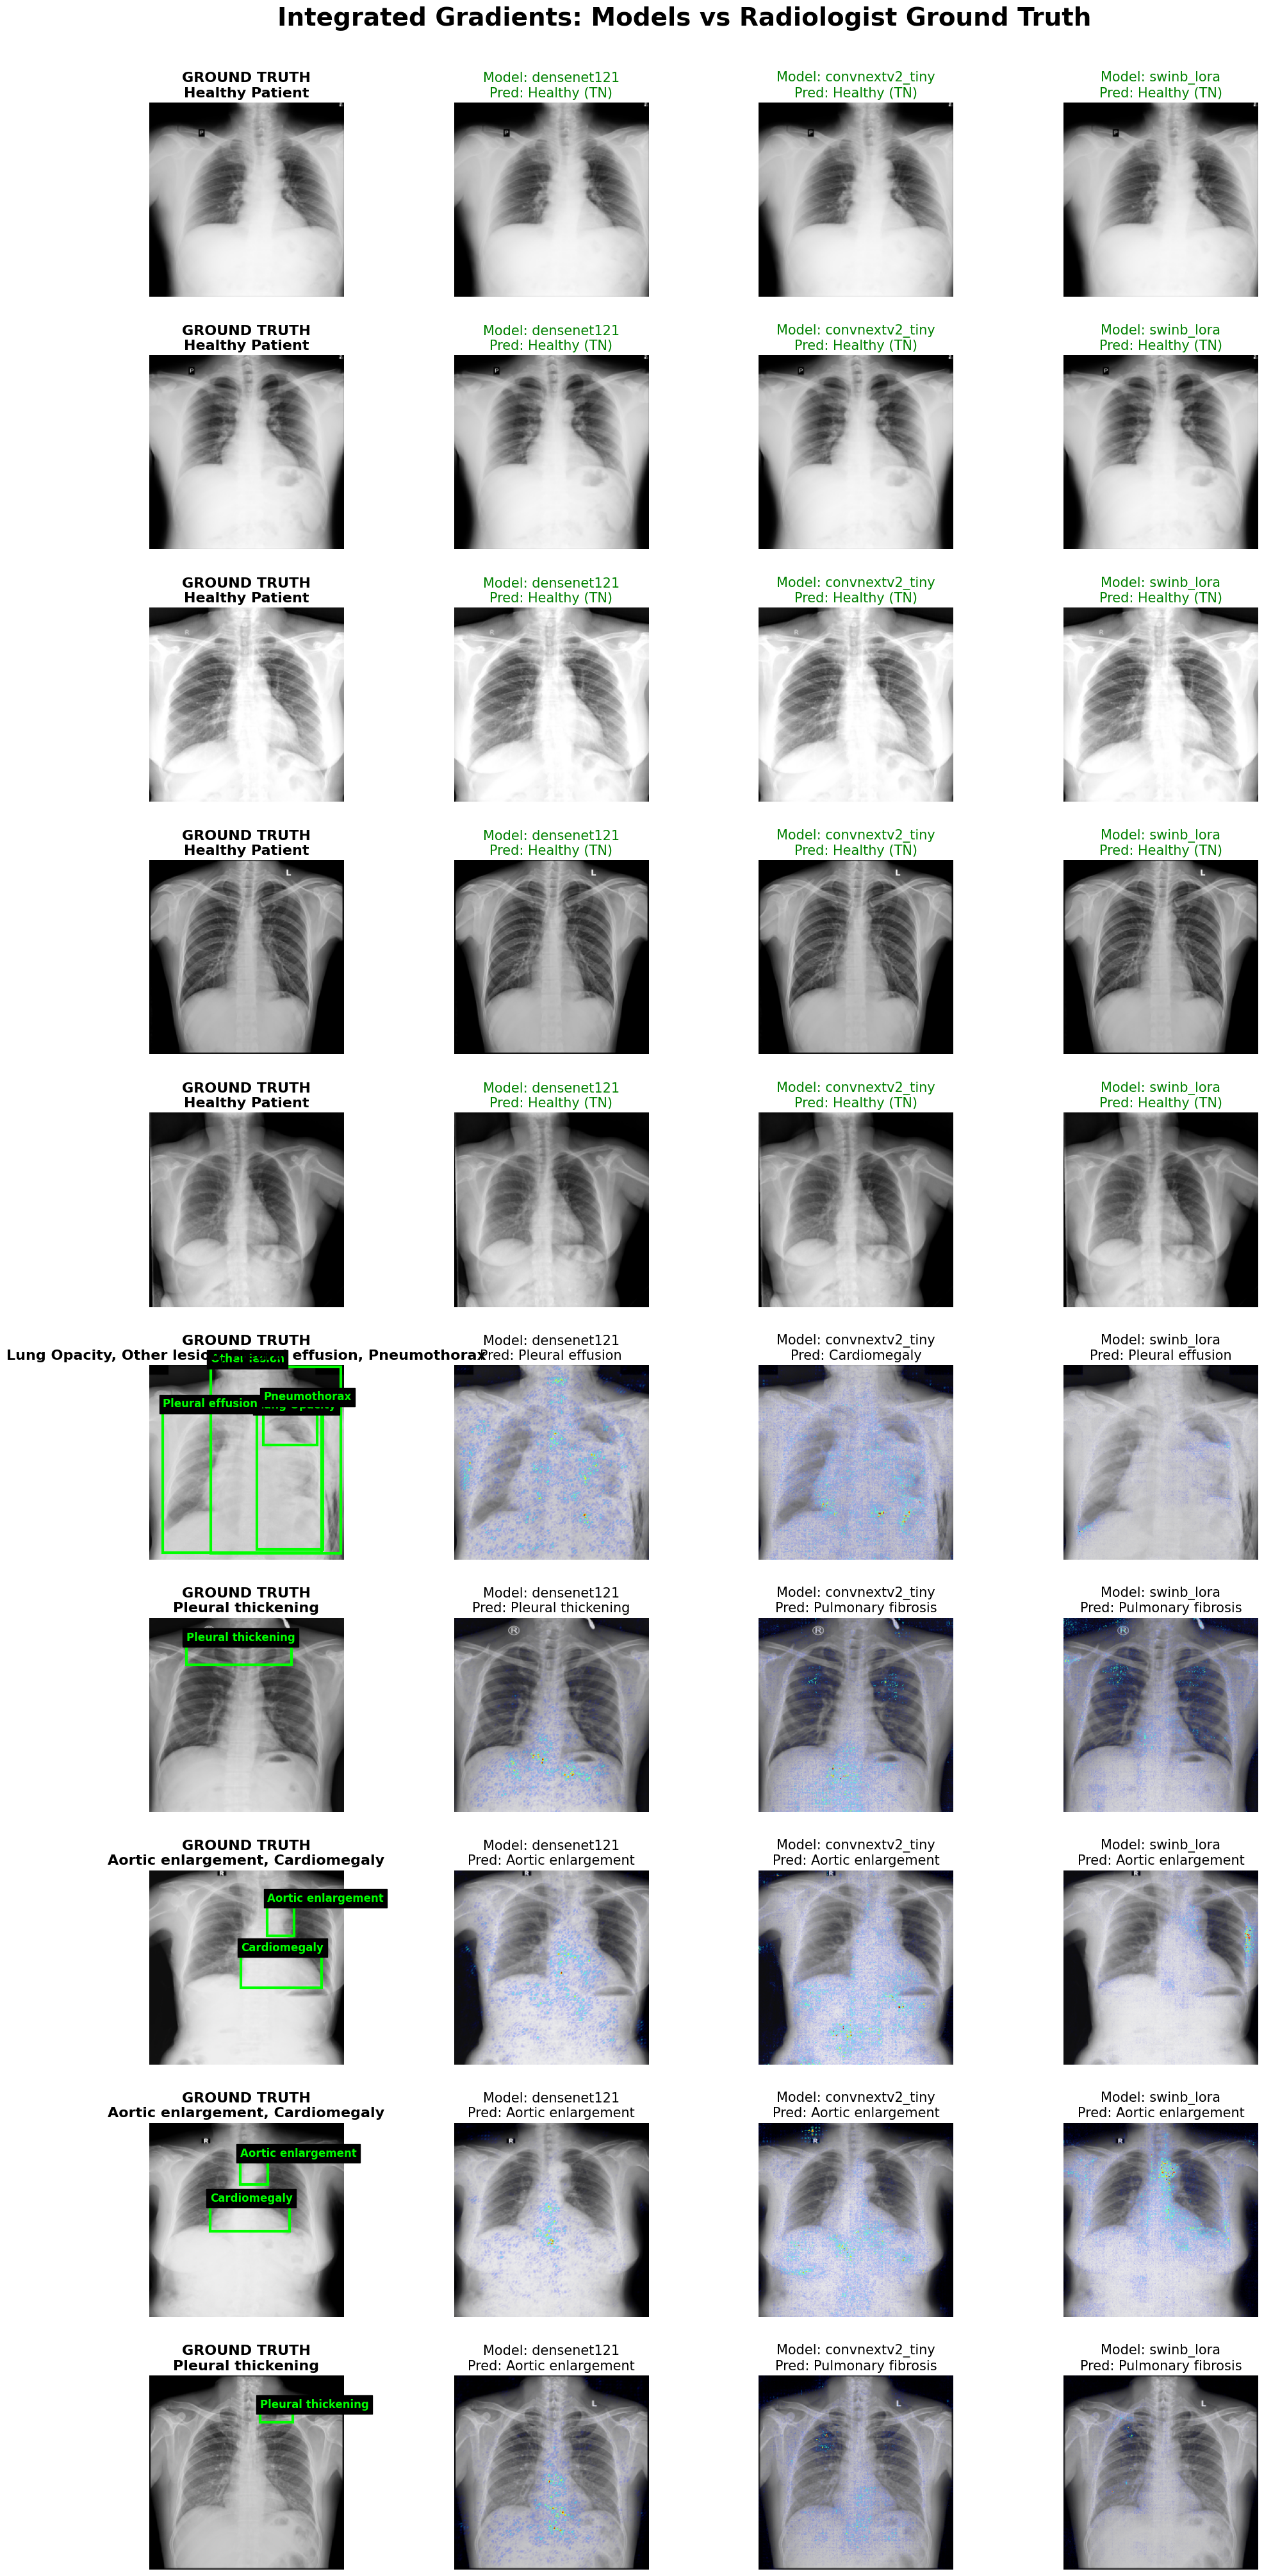

In [16]:
# ==============================================================================
# IG MAP VISUALIZATION GRID
# ==============================================================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import random

print("🎨 Generating IG Map Visualization Grid...")

# 1. Define Paths (Independent of upper cells)
ROOT = Path('/content/drive/MyDrive/cxr_faithfulness')
IMAGES_PATH = ROOT / 'data' / 'processed' / 'images'
SPLITS_PATH = ROOT / 'data' / 'processed' / 'splits'
RESULTS_PATH = ROOT / 'results'
IG_PATH = ROOT / 'ig_maps'
CONSENSUS_PATH = ROOT / 'data' / 'processed' / 'consensus' / 'consensus_boxes_2of3.csv'

SAVE_DIR = RESULTS_PATH / 'sample heatmap'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = ['densenet121', 'convnextv2_tiny', 'swinb_lora']

# 2. Load Metadata
manifest_df = pd.read_csv(RESULTS_PATH / 'ig_manifest.csv')
test_patho = pd.read_csv(SPLITS_PATH / 'test_patho.csv')
test_healthy = pd.read_csv(SPLITS_PATH / 'test_healthy.csv')

if CONSENSUS_PATH.exists():
    boxes_df = pd.read_csv(CONSENSUS_PATH)
else:
    boxes_df = pd.DataFrame(columns=['image_id', 'class_name', 'x_min', 'y_min', 'x_max', 'y_max'])

# 3. Pick 5 healthy and 5 patho images randomly
random.seed(42) # Change this seed number to see a different set of 10 patients
healthy_ids = random.sample(test_healthy['image_id'].tolist(), 5)
patho_ids = random.sample(test_patho['image_id'].tolist(), 5)
selected_ids = healthy_ids + patho_ids

# 4. Setup Plot Grid (10 rows, 4 columns)
fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(24, 50))
plt.subplots_adjust(wspace=0.1, hspace=0.3)

for row_idx, image_id in enumerate(selected_ids):
    is_healthy = image_id in healthy_ids

    # --- Column 0: Original X-ray + Radiologist Ground Truth ---
    ax_gt = axes[row_idx, 0]
    img_path = IMAGES_PATH / f"{image_id}.png"

    if img_path.exists():
        raw_img = cv2.imread(str(img_path))
        raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    else:
        raw_img = np.zeros((224, 224, 3), dtype=np.uint8)

    ax_gt.imshow(raw_img)

    # Draw radiologist consensus boxes
    img_boxes = boxes_df[boxes_df['image_id'] == image_id]
    true_labels = []
    for _, box_row in img_boxes.iterrows():
        xmin, ymin, xmax, ymax = box_row['x_min'], box_row['y_min'], box_row['x_max'], box_row['y_max']
        label = box_row['class_name']
        if label not in true_labels:
            true_labels.append(label)

        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 linewidth=3, edgecolor='lime', facecolor='none')
        ax_gt.add_patch(rect)
        ax_gt.text(xmin, ymin - 5, label, color='lime', fontsize=12, fontweight='bold', backgroundcolor='black')

    if is_healthy:
        title_gt = "GROUND TRUTH\nHealthy Patient"
    else:
        title_gt = f"GROUND TRUTH\n{', '.join(true_labels)}" if true_labels else "GROUND TRUTH\nPatho (No Box)"

    ax_gt.set_title(title_gt, fontsize=16, fontweight='bold')
    ax_gt.axis('off')

    # --- Columns 1 to 3: The 3 Models ---
    for col_idx, model_name in enumerate(MODEL_NAMES, start=1):
        ax_mod = axes[row_idx, col_idx]

        # Check if the model hallucinated/predicted a class and generated a heatmap
        man_row = manifest_df[(manifest_df['image_id'] == image_id) & (manifest_df['model'] == model_name)]

        if not man_row.empty:
            # Heatmap exists
            pred_class = man_row.iloc[0]['target_class']
            ig_file = IG_PATH / f"{image_id}_{model_name}_ig.npy"

            if ig_file.exists():
                ig_map = np.load(str(ig_file))
                if ig_map.shape != (raw_img.shape[0], raw_img.shape[1]):
                    ig_map = cv2.resize(ig_map, (raw_img.shape[1], raw_img.shape[0]))

                # Convert IG map to a colorful JET heatmap
                heatmap_rgb = cv2.applyColorMap(np.uint8(255 * ig_map), cv2.COLORMAP_JET)
                heatmap_rgb = cv2.cvtColor(heatmap_rgb, cv2.COLOR_BGR2RGB)

                # Smoothly blend the heatmap over the X-ray using the IG values as transparency
                alpha = np.clip(ig_map * 1.5, 0, 1)[:, :, np.newaxis]
                overlay = (raw_img * (1 - alpha) + heatmap_rgb * alpha).astype(np.uint8)

                ax_mod.imshow(overlay)
                ax_mod.set_title(f"Model: {model_name}\nPred: {pred_class}", fontsize=15)
            else:
                ax_mod.imshow(raw_img)
                ax_mod.set_title(f"{model_name}\n[IG File Missing]", fontsize=15, color='red')
        else:
            # No manifest entry -> Model correctly predicted Healthy (True Negative)
            ax_mod.imshow(raw_img)
            ax_mod.set_title(f"Model: {model_name}\nPred: Healthy (TN)", fontsize=15, color='green')

        ax_mod.axis('off')

# Save and Display
plt.suptitle("Integrated Gradients: Models vs Radiologist Ground Truth", fontsize=28, y=0.91, fontweight='bold')
save_path = SAVE_DIR / 'ig_sample_grid.png'
plt.savefig(str(save_path), bbox_inches='tight', dpi=150)
print(f"✅ Visualization saved successfully to: {save_path}")
plt.show()